In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
df = pd.read_csv("ABC_Employee.csv")
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

In [9]:
np.random.seed(42)
df["Height"] = np.random.randint(150,181,size=len(df))
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,156,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,169,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,178,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,160,231,NaN,5000000.0


In [10]:
#Distribution of Employees Across Teams
team_count = df["Team"].value_counts()
team_percentage = (team_count/len(df))*100
team_summary = pd.DataFrame({
    "Employees":team_count,
    "Percentage":team_percentage
})
team_summary

,Employees,Percentage
Team,,
New Orleans Pelicans,19,4.148472
Memphis Grizzlies,18,3.930131
Utah Jazz,16,3.493450
New York Knicks,16,3.493450
Milwaukee Bucks,16,3.493450
Brooklyn Nets,15,3.275109
Portland Trail Blazers,15,3.275109
Oklahoma City Thunder,15,3.275109
Denver Nuggets,15,3.275109


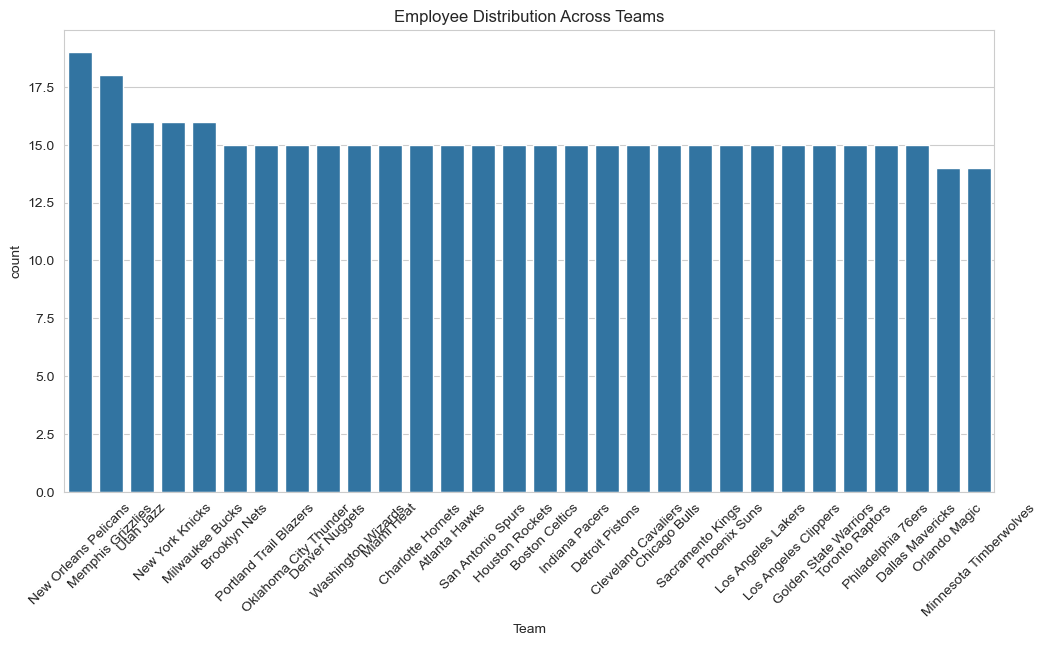

In [11]:
#Graph
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="Team",order=df["Team"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Employee Distribution Across Teams")
plt.show()

In [12]:
#Segregate Employees Based on Position
position_count = df["Position"].value_counts()
position_count

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

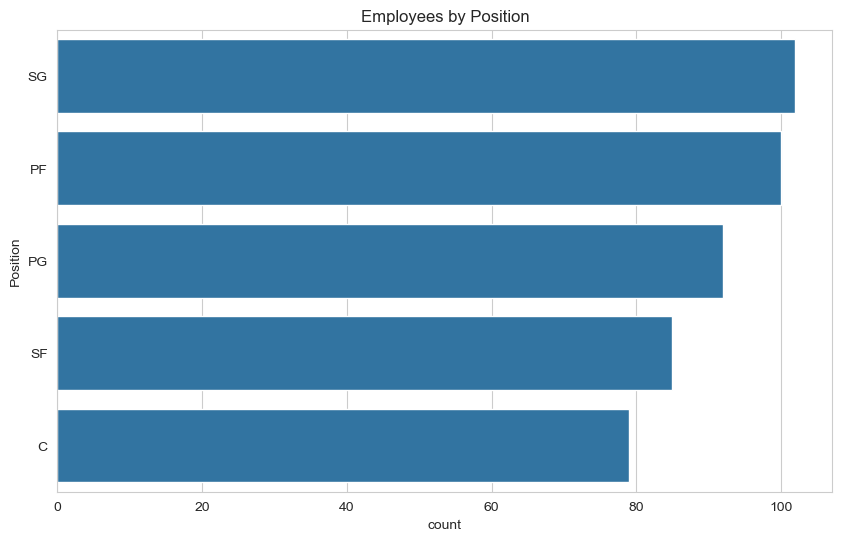

In [13]:
#Graph
plt.figure(figsize=(10,6))
sns.countplot(data=df,y="Position",order=df["Position"].value_counts().index)
plt.title("Employees by Position")
plt.show()

In [14]:
#Predominant Age Group
bins=[18,25,30,35,40,45,50]
labels=["18-25","26-30","31-35","36-40","41-45","46-50"]
df["Age Group"]=pd.cut(df["Age"],bins=bins,labels=labels)
age_group=df["Age Group"].value_counts()
age_group

Age Group
18-25    200
26-30    167
31-35     68
36-40     23
41-45      0
46-50      0
Name: count, dtype: int64

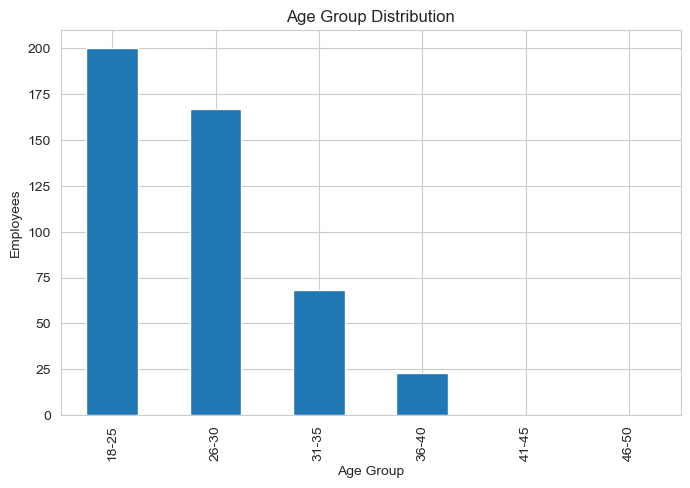

In [15]:
#Graph
plt.figure(figsize=(8,5))
age_group.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Employees")
plt.show()

In [16]:
#Team with Highest Salary Expenditure
team_salary=df.groupby("Team")["Salary"].sum().sort_values(ascending=False)
team_salary

Team
Cleveland Cavaliers       106988689.0
Los Angeles Clippers       94854640.0
Oklahoma City Thunder      93765298.0
Golden State Warriors      88868997.0
Chicago Bulls              86783378.0
San Antonio Spurs          84442733.0
New Orleans Pelicans       82750774.0
Miami Heat                 82515673.0
Charlotte Hornets          78340920.0
Memphis Grizzlies          76550880.0
Washington Wizards         76328636.0
Houston Rockets            75283021.0
New York Knicks            73303898.0
Atlanta Hawks              72902950.0
Los Angeles Lakers         71770431.0
Sacramento Kings           71683666.0
Dallas Mavericks           71198732.0
Toronto Raptors            71117611.0
Milwaukee Bucks            69603517.0
Detroit Pistons            67168263.0
Indiana Pacers             66751826.0
Utah Jazz                  64007367.0
Phoenix Suns               63445135.0
Orlando Magic              60161470.0
Denver Nuggets             60121930.0
Minnesota Timberwolves     59709697.0
Boston 

In [17]:
position_salary=df.groupby("Position")["Salary"].sum().sort_values(ascending=False)
position_salary

Position
C     466377332.0
PG    446848971.0
PF    442560850.0
SF    408020976.0
SG    396976258.0
Name: Salary, dtype: float64

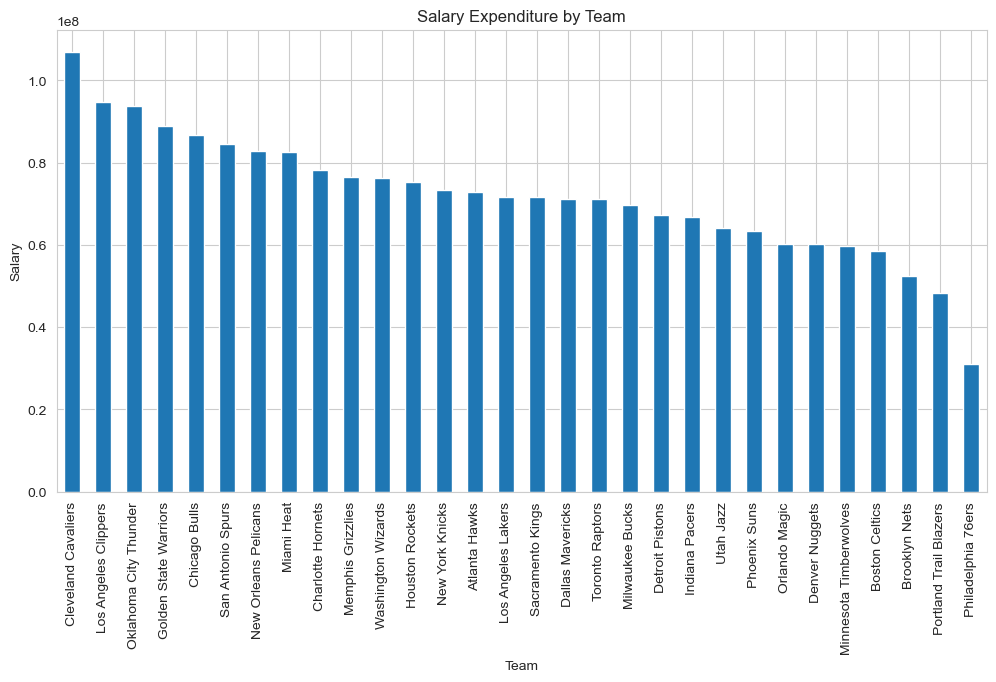

In [18]:
plt.figure(figsize=(12,6))
team_salary.plot(kind="bar")
plt.title("Salary Expenditure by Team")
plt.ylabel("Salary")
plt.show()

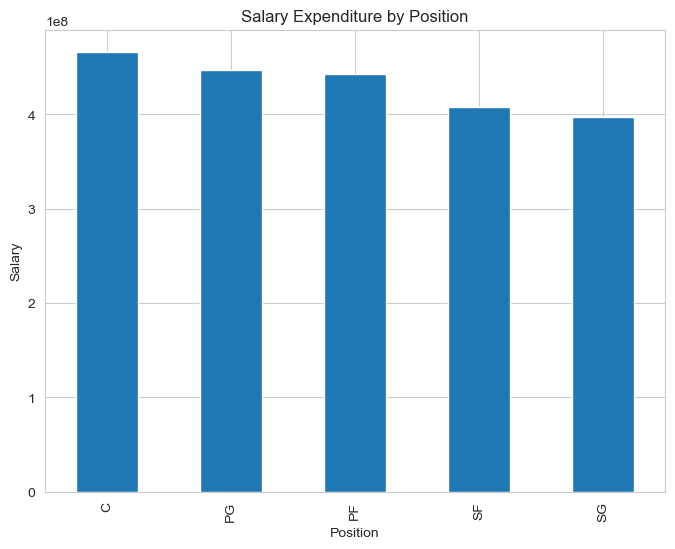

In [19]:
plt.figure(figsize=(8,6))
position_salary.plot(kind="bar")
plt.title("Salary Expenditure by Position")
plt.ylabel("Salary")
plt.show()

In [20]:
#Correlation Between Age and Salary
correlation=df["Age"].corr(df["Salary"])
print(correlation)

0.21400941226570985


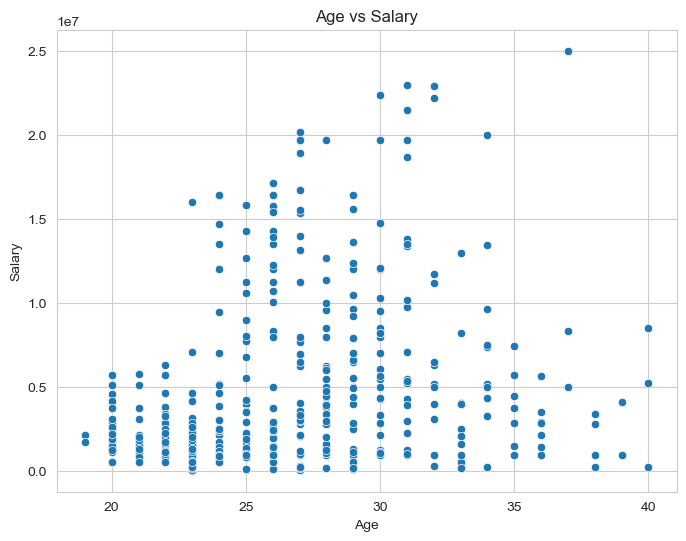

In [22]:
#ScatterPLot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x="Age",y="Salary")
plt.title("Age vs Salary")
plt.show()

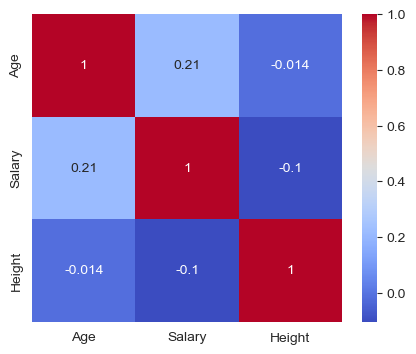

In [23]:
#Correlation Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age","Salary","Height"]].corr(),
            annot=True,
            cmap="coolwarm")
plt.show()